# Preprocessing & EDA
## Healthcare Sector Focus

**Goal**: Analyse the UK ICO data security incident trends with a focus on the healthcare sector to prepare for building ML models and a dashboard.


In [137]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes

In [138]:
# load the dataset
df_ico_original = pd.read_csv("data-security-incidents-trends-q1-2019-to-q2-2025.csv", delimiter = ",")

# initial look at data
df_ico_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188251 entries, 0 to 188250
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                188251 non-null  object
 1   Year                        188251 non-null  int64 
 2   Quarter                     188251 non-null  object
 3   Data Subject Type           188251 non-null  object
 4   Data Type                   188251 non-null  object
 5   Decision Taken              188251 non-null  object
 6   Incident Category           188251 non-null  object
 7   Incident Type               188251 non-null  object
 8   No. Data Subjects Affected  188251 non-null  object
 9   Sector                      188251 non-null  object
 10  Time Taken to Report        188251 non-null  object
dtypes: int64(1), object(10)
memory usage: 15.8+ MB



Total sectors: 23


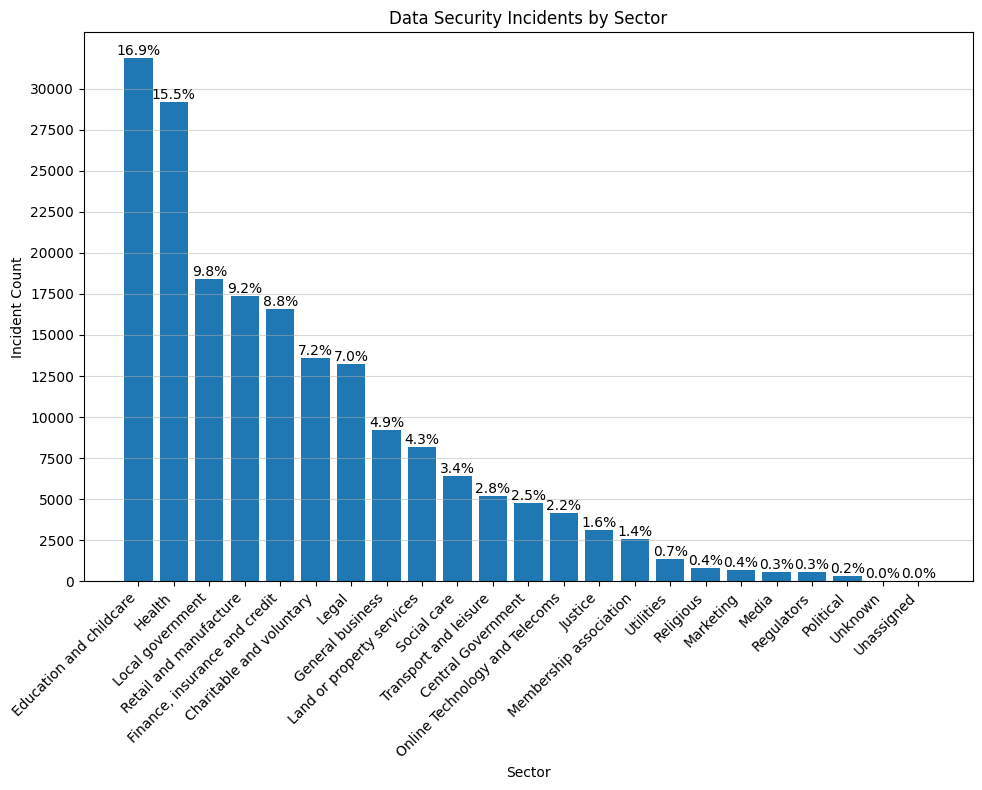

In [139]:
# count all sectors
sector_counts = df_ico_original['Sector'].value_counts()
sector_percents = sector_counts / len(df_ico_original) * 100

plt.figure(figsize=(10, 8))
bars = plt.bar(sector_counts.index, sector_counts.values)

plt.title("Data Security Incidents by Sector")
plt.xlabel("Sector")
plt.ylabel("Incident Count")
plt.xticks(rotation=45, ha='right')
plt.yticks(np.arange(0, max(sector_counts.values) + 1, 2500))

# add percentage labels on top of each bar
for bar, percent in zip(bars, sector_percents):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # put percentage in the middle
        height, f"{percent:.1f}%",
        ha='center', va='bottom'
    )

print(f"\nTotal sectors: {df_ico_original['Sector'].nunique()}")
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

In [140]:
# Sector table with counts and percentages
sector_table = pd.DataFrame({
    'Incident Count': sector_counts,
    'Percentage': sector_percents.round(3)
})
sector_table


,Incident Count,Percentage
Sector,,
Education and childcare,31832,16.909
Health,29198,15.510
Local government,18383,9.765
Retail and manufacture,17394,9.240
"Finance, insurance and credit",16554,8.794
Charitable and voluntary,13617,7.233
Legal,13221,7.023
General business,9211,4.893
Land or property services,8159,4.334


In [141]:
# filtering the database to focus of the health sector
df_health_original = df_ico_original[df_ico_original["Sector"] == "Health"].copy(deep=True)

# drop the sector column as it's redundant now
df_health_original = df_health_original.drop(columns=["Sector"])

# standardising the column names
df_health_original.columns = df_health_original.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(".", "")

# look at new healthcare sector focused df
df_health_original.info()
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 29198 entries, 12 to 188238
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   bi_reference               29198 non-null  object
 1   year                       29198 non-null  int64 
 2   quarter                    29198 non-null  object
 3   data_subject_type          29198 non-null  object
 4   data_type                  29198 non-null  object
 5   decision_taken             29198 non-null  object
 6   incident_category          29198 non-null  object
 7   incident_type              29198 non-null  object
 8   no_data_subjects_affected  29198 non-null  object
 9   time_taken_to_report       29198 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.5+ MB


In [142]:
# filtering timeframe to Q2 2021 to Q2 2025

# Get quarters as int for filtering
df_health_original["quarter_num"] = df_health_original["quarter"].str.extract(r"(\d)").astype(int) # temp, helper column 

df_health_original = df_health_original[
    ((df_health_original["year"] > 2021) | ((df_health_original["year"] == 2021) & (df_health_original["quarter_num"] >= 2))) &
    ((df_health_original["year"] < 2025) | ((df_health_original["year"] == 2025) & (df_health_original["quarter_num"] <= 2)))
]

df_health_original = df_health_original.drop(columns="quarter_num") # drop 

# Test to see full timeframe
print(df_health_original[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]).to_string(index=False))

# New CSV of all processed data
df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

 year quarter
 2021   Qtr 2
 2021   Qtr 3
 2021   Qtr 4
 2022   Qtr 1
 2022   Qtr 2
 2022   Qtr 3
 2022   Qtr 4
 2023   Qtr 1
 2023   Qtr 2
 2023   Qtr 3
 2023   Qtr 4
 2024   Qtr 1
 2024   Qtr 2
 2024   Qtr 3
 2024   Qtr 4
 2025   Qtr 1
 2025   Qtr 2


In [143]:
# change data type of features into categorical instead of object/ int as characteristics are fixed
categorical_cols = [
    "bi_reference",
    "year",
    "quarter",
    "data_subject_type",
    "data_type",
    "decision_taken",
    "incident_category",
    "incident_type",
    "no_data_subjects_affected",
    "time_taken_to_report"
]

for col in categorical_cols:
    df_health_original[col] = df_health_original[col].astype("category")

# verify new data types
df_health_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19950 entries, 65264 to 188238
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               19950 non-null  category
 1   year                       19950 non-null  category
 2   quarter                    19950 non-null  category
 3   data_subject_type          19950 non-null  category
 4   data_type                  19950 non-null  category
 5   decision_taken             19950 non-null  category
 6   incident_category          19950 non-null  category
 7   incident_type              19950 non-null  category
 8   no_data_subjects_affected  19950 non-null  category
 9   time_taken_to_report       19950 non-null  category
dtypes: category(10)
memory usage: 700.0 KB


In [144]:
# Order the data subjects affected category
df_health_original["no_data_subjects_affected"] = pd.Categorical(
    df_health_original["no_data_subjects_affected"],
    categories=[
        "1 to 9",
        "10 to 99",
        "100 to 1k",
        "1k to 10k",
        "10k to 100k",
        "100k and above",
        "Unknown"
    ],
    ordered=True
)

# verify ordering
df_health_original["no_data_subjects_affected"].cat.categories

Index(['1 to 9', '10 to 99', '100 to 1k', '1k to 10k', '10k to 100k',
       '100k and above', 'Unknown'],
      dtype='object')

In [145]:
# finding the unique vs total BI references 
total_rows = len(df_health_original)
unique_bi_refs = df_health_original['bi_reference'].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"\nTotal rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")


Total rows in the dataset: 19,950
Unique BI References: 8,801
Rows representing duplicate characteristics: 11,149
Duplication rate: 55.88%


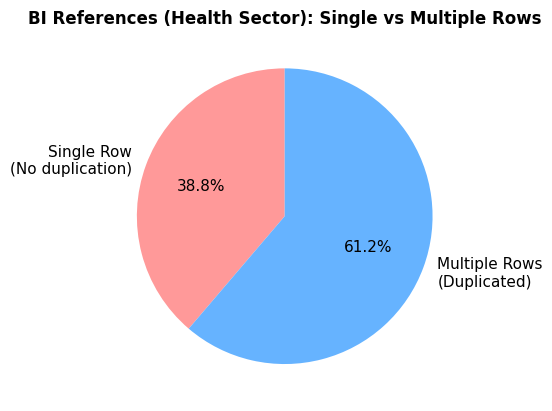

In [146]:
# plot: pie chart of unique vs duplicate references
bi_ref_counts = df_health_original['bi_reference'].value_counts()
single_row = (bi_ref_counts == 1).sum()
multiple_rows = (bi_ref_counts > 1).sum()

plt.pie([single_row, multiple_rows], 
            labels=['Single Row\n(No duplication)', 'Multiple Rows\n(Duplicated)'], 
            autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'],
            startangle=90,
            textprops={'fontsize': 11})

plt.title('BI References (Health Sector): Single vs Multiple Rows', fontsize=12, fontdict={'weight': 'bold'})
plt.show()

In [147]:
# analyse which columns typically vary across duplicates
duplicated_bi_refs = df_health_original[df_health_original['bi_reference'].duplicated(keep=False)]
total_groups = duplicated_bi_refs['bi_reference'].nunique()

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# a column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

varying_counts = (varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

varying_counts["percentage"] = (varying_counts["count"] / total_groups * 100)

print(f"Columns that vary across duplicate rows:\n {varying_counts}")

# summarise how many characteristics each breach has
print("\nBreach characteristics per incident:")
df_health_original.groupby("bi_reference", observed=False).size().describe()

Columns that vary across duplicate rows:
                            count  percentage
data_type                   4889   90.705009
data_subject_type           1461   27.105751
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:


count    8801.000000
mean        2.266788
std         2.819888
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        66.000000
dtype: float64

Missing values in the healthcare dataset:
bi_reference                 0
year                         0
quarter                      0
data_subject_type            0
data_type                    0
decision_taken               0
incident_category            0
incident_type                0
no_data_subjects_affected    0
time_taken_to_report         0
dtype: int64


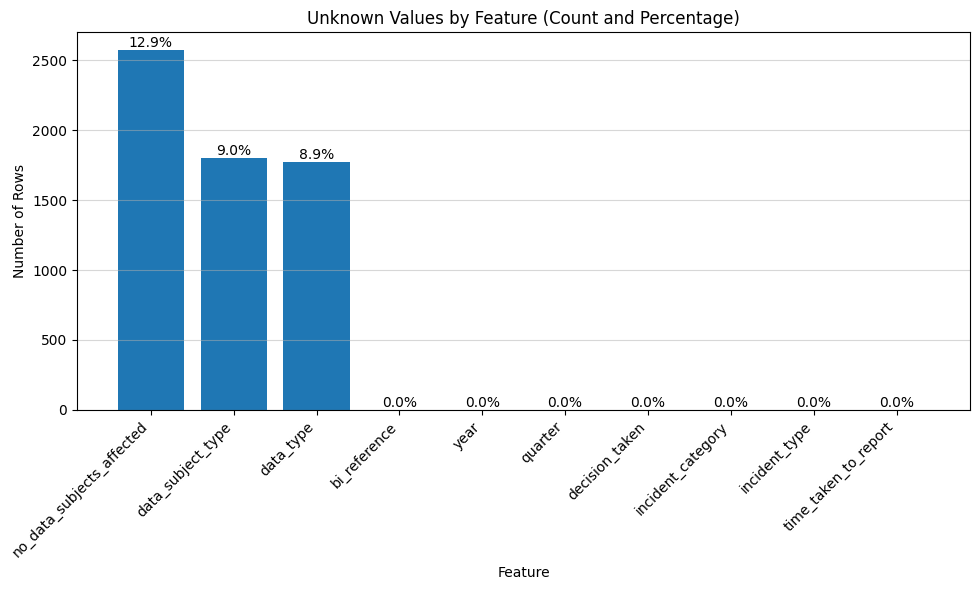

Unknown characteristic counts in each feature:
no_data_subjects_affected    2571
data_subject_type            1804
data_type                    1776
bi_reference                    0
year                            0
quarter                         0
decision_taken                  0
incident_category               0
incident_type                   0
time_taken_to_report            0
dtype: int64


In [148]:
# checking how many missing/ unknown values are in the healthcare df
print(f"Missing values in the healthcare dataset:\n{df_health_original.isnull().sum()}")

unknown_counts = df_health_original[categorical_cols].isin(["Unknown"]).sum().sort_values(ascending=False)

# calculate percentages
unknown_percents = (unknown_counts / len(df_health_original)) * 100

# visualise per feature
plt.figure(figsize=(10, 6))
bars = plt.bar(unknown_counts.index, unknown_counts.values)

plt.title("Unknown Values by Feature (Count and Percentage)")
plt.xlabel("Feature")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45, ha="right")

# add percentage labels
for bar, percent in zip(bars, unknown_percents):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height, f"{percent:.1f}%",
        ha="center", va="bottom"
    )

plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Unknown characteristic counts in each feature:\n{unknown_counts}")

In [149]:
# Create a new df that only contains unique BI references (deduplicated)
df_health_unique = df_health_original.drop_duplicates(subset=["bi_reference"], keep="first").reset_index(drop=True)
print("Unique Rows in Health Sector df:",unique_bi_refs)

Unique Rows in Health Sector df: 8801


In [150]:
# aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_original
    .groupby(["year", "quarter"], observed=True) 
    .size()
    .reset_index(name="total_incidents")
)

# aggregate unique incidents per year-quarter (non-duplicated BI references)
unique_incidents = (
    df_health_unique
    .groupby(["year", "quarter"], observed=True)  
    .size()
    .reset_index(name="unique_incidents")
)

quarters = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

# merge the two summaries
incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])

# make the chronological order
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarters)

# convert year to int for sorting
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)

# x-axis label
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# copy for display purposes
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
# calculate the difference (duplicate count) & percentage of duplicates
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
# display columns
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates"]

# tabular form
print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

# summary statistics
print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")

# mean and standard deviations of unique incidents over time 
print(f"\tMean incidents per quarter: {display_df['Unique Incidents'].mean():.1f}")
print(f"\tStandard deviation of incidents: {display_df['Unique Incidents'].std():.1f}")
print(f"\tMaximum incidents in a quarter: {display_df['Unique Incidents'].max():,}")
print(f"\tMinimum incidents in a quarter: {display_df['Unique Incidents'].min():,}")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates
2021   Qtr 2        1286               603         683
2021   Qtr 3         915               432         483
2021   Qtr 4         991               461         530
2022   Qtr 1         913               421         492
2022   Qtr 2         937               431         506
2022   Qtr 3        1548               481        1067
2022   Qtr 4         938               440         498
2023   Qtr 1        1077               454         623
2023   Qtr 2        1019               458         561
2023   Qtr 3        1038               501         537
2023   Qtr 4        1191               503         688
2024   Qtr 1        1245               572         673
2024   Qtr 2        1497               616         881
2024   Qtr 3        1620               677         943
2024   Qtr 4        1154               577         577
2025   Qtr 1        1236               584         652
2025   Qtr 2       

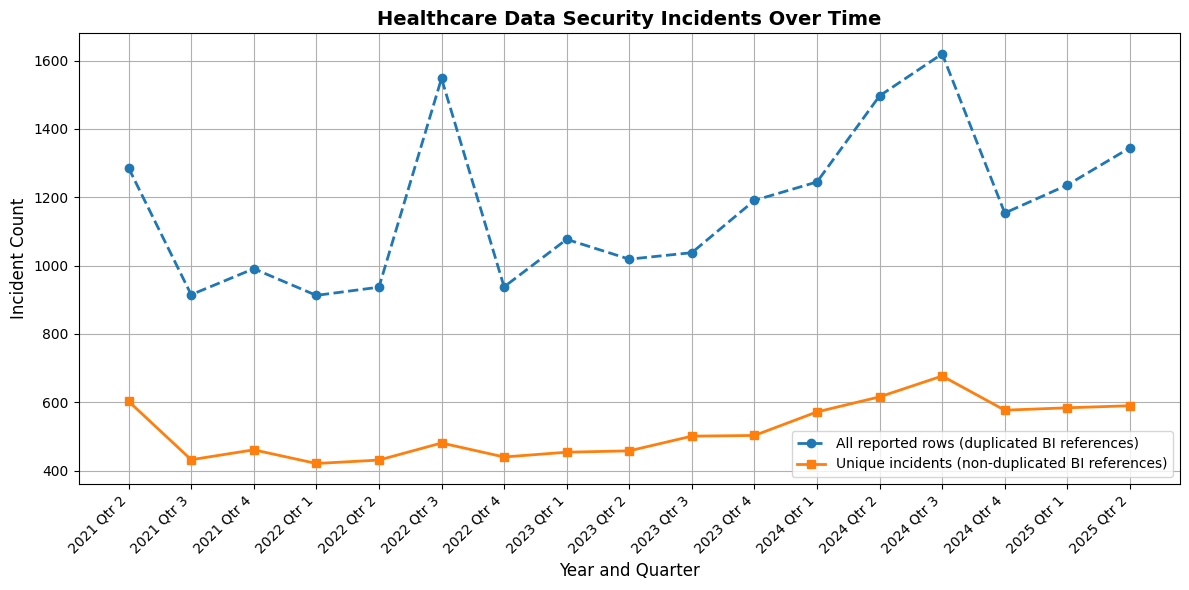

In [151]:
# graph visualisation of incidents 
plt.figure(figsize=(12, 6))

plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker='o',
    label="All reported rows (duplicated BI references)",
    linestyle="--",
    linewidth=2,
    markersize=6
)

plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker='s',
    label="Unique incidents (non-duplicated BI references)",
    linewidth=2,
    markersize=6
)

plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha='right'
)

plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='-')
plt.tight_layout()
plt.show()

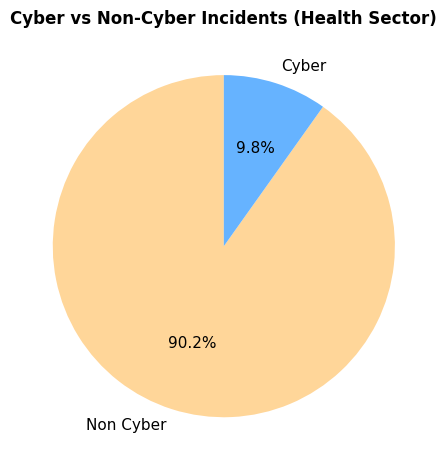

Incident category counts (Cyber vs Non-cyber):
Cyber: 866 
Non-Cyber: 7,935


In [152]:
# cyber vs non-cyber incidents
incident_category_counts = df_health_unique['incident_category'].value_counts()
incident_category_percents = (incident_category_counts / len(df_health_original)) * 100

plt.title("Cyber vs Non-Cyber Incidents (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(incident_category_counts.values,
        labels=incident_category_counts.index,
        autopct='%1.1f%%',
        colors=["#ffd699", "#66b3ff"],
        startangle=90,
        textprops={'fontsize': 11})

plt.tight_layout()
plt.show()
print(f"Incident category counts (Cyber vs Non-cyber):\nCyber: {incident_category_counts['Cyber']:,} \nNon-Cyber: {incident_category_counts['Non Cyber']:,}")

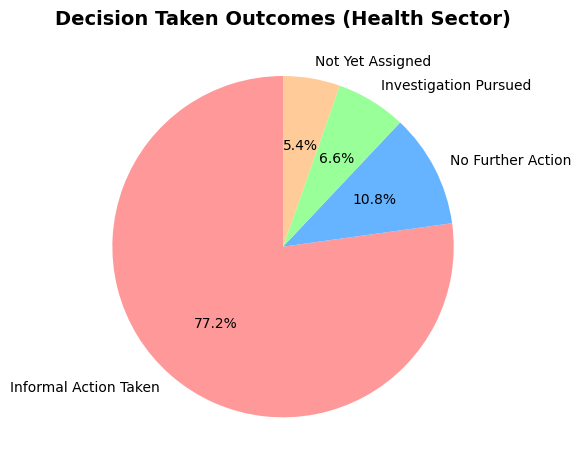

Decision taken counts:
Informal Action Taken:	6,794 
No Further Action:	948 
Investigation Pursued:	585 
Not Yet Assigned:	474


In [153]:
# decision taken outcomes
decision_counts = df_health_unique['decision_taken'].value_counts()
decision_percents = (decision_counts / len(df_health_original)) * 100

# pie chart
plt.title("Decision Taken Outcomes (Health Sector)", fontsize=14, fontweight='bold')
plt.pie(decision_counts.values,
        labels=decision_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 10})

plt.tight_layout()
plt.show()

print(f"Decision taken counts:\nInformal Action Taken:\t{decision_counts['Informal Action Taken']:,} \nNo Further Action:\t{decision_counts['No Further Action']:,} \nInvestigation Pursued:\t{decision_counts['Investigation Pursued']:,} \nNot Yet Assigned:\t{decision_counts['Not Yet Assigned']:,}")


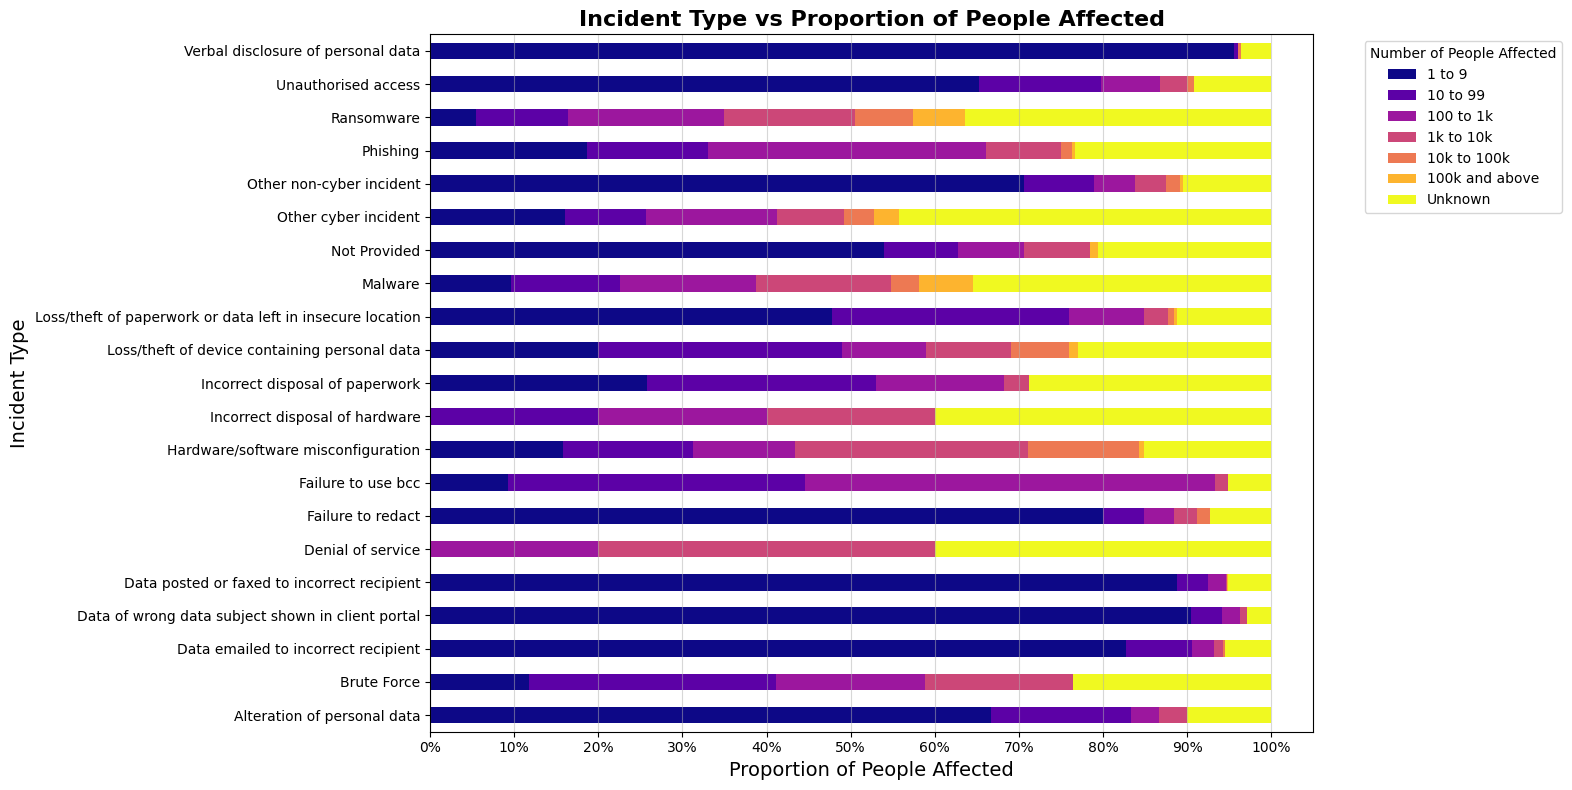

no_data_subjects_affected,1 to 9,10 to 99,100 to 1k,1k to 10k,10k to 100k,100k and above,Unknown
incident_type,,,,,,,
Alteration of personal data,0.667,0.167,0.033,0.033,0.000,0.000,0.100
Brute Force,0.118,0.294,0.176,0.176,0.000,0.000,0.235
Data emailed to incorrect recipient,0.828,0.078,0.026,0.011,0.002,0.000,0.055
Data of wrong data subject shown in client portal,0.904,0.038,0.021,0.008,0.000,0.000,0.029
Data posted or faxed to incorrect recipient,0.888,0.037,0.021,0.001,0.000,0.001,0.052
Denial of service,0.000,0.000,0.200,0.400,0.000,0.000,0.400
Failure to redact,0.799,0.049,0.036,0.027,0.015,0.000,0.073
Failure to use bcc,0.092,0.354,0.487,0.015,0.000,0.000,0.051
Hardware/software misconfiguration,0.158,0.155,0.122,0.276,0.132,0.007,0.151


In [154]:
# incident type vs data subjects affected

# proportions
incident_severity_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['no_data_subjects_affected'],
    normalize='index'
)
# counts
incident_severity_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['no_data_subjects_affected']
)
# horizontal bar chart
incident_severity_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)

plt.title('Incident Type vs Proportion of People Affected', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Proportion of People Affected', fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Number of People Affected', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# display the incident type vs data subjects affected proportions
incident_severity_proportions.round(3)

In [155]:
# display the incident type vs data subjects affected counts
incident_severity_counts

no_data_subjects_affected,1 to 9,10 to 99,100 to 1k,1k to 10k,10k to 100k,100k and above,Unknown
incident_type,,,,,,,
Alteration of personal data,20,5,1,1,0,0,3
Brute Force,2,5,3,3,0,0,4
Data emailed to incorrect recipient,1115,105,35,15,3,0,74
Data of wrong data subject shown in client portal,217,9,5,2,0,0,7
Data posted or faxed to incorrect recipient,790,33,19,1,0,1,46
Denial of service,0,0,1,2,0,0,2
Failure to redact,263,16,12,9,5,0,24
Failure to use bcc,18,69,95,3,0,0,10
Hardware/software misconfiguration,48,47,37,84,40,2,46


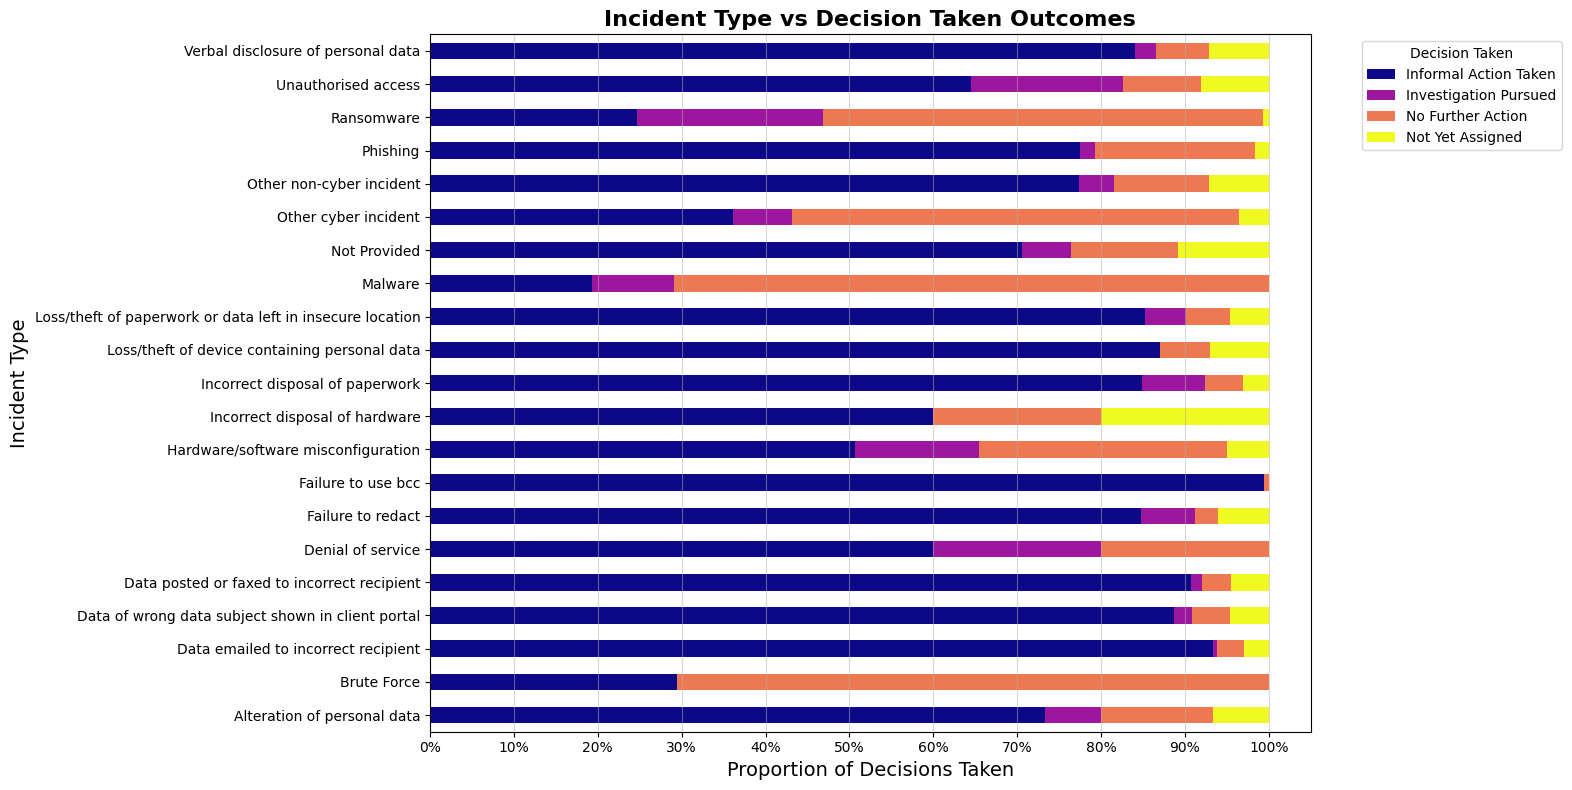

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
incident_type,,,,
Alteration of personal data,0.733,0.067,0.133,0.067
Brute Force,0.294,0.000,0.706,0.000
Data emailed to incorrect recipient,0.933,0.005,0.033,0.029
Data of wrong data subject shown in client portal,0.888,0.021,0.046,0.046
Data posted or faxed to incorrect recipient,0.908,0.012,0.035,0.045
Denial of service,0.600,0.200,0.200,0.000
Failure to redact,0.848,0.064,0.027,0.061
Failure to use bcc,0.995,0.000,0.005,0.000
Hardware/software misconfiguration,0.507,0.148,0.296,0.049


In [156]:
# decision taken vs incident Type

# proportions
incident_type_decision_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
incident_type_decision_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['decision_taken']
)
# horizontal bar chart
incident_type_decision_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)
plt.title('Incident Type vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Proportion of Decisions Taken', fontsize=14)
plt.ylabel('Incident Type', fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs decision taken proportions
incident_type_decision_proportions.round(3)

In [157]:
# table for the incident type vs decision taken counts
incident_type_decision_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
incident_type,,,,
Alteration of personal data,22,2,4,2
Brute Force,5,0,12,0
Data emailed to incorrect recipient,1257,7,44,39
Data of wrong data subject shown in client portal,213,5,11,11
Data posted or faxed to incorrect recipient,808,11,31,40
Denial of service,3,1,1,0
Failure to redact,279,21,9,20
Failure to use bcc,194,0,1,0
Hardware/software misconfiguration,154,45,90,15


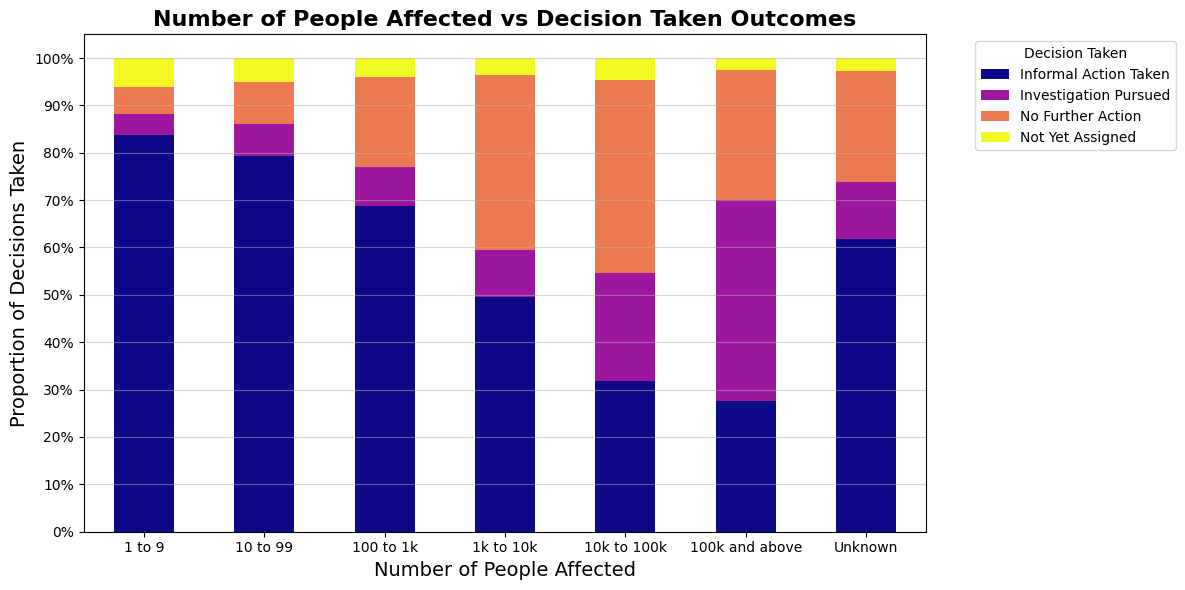

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
no_data_subjects_affected,,,,
1 to 9,0.836,0.046,0.055,0.062
10 to 99,0.792,0.069,0.087,0.051
100 to 1k,0.687,0.083,0.191,0.039
1k to 10k,0.496,0.100,0.368,0.036
10k to 100k,0.318,0.227,0.409,0.045
100k and above,0.275,0.425,0.275,0.025
Unknown,0.617,0.122,0.234,0.027


In [158]:
# decision taken vs no. data subjects affected

# proportions
decision_severity_proportions = pd.crosstab(
    df_health_unique['no_data_subjects_affected'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
decision_severity_counts = pd.crosstab(
    df_health_unique['no_data_subjects_affected'],
    df_health_unique['decision_taken']
)
# bar chart
decision_severity_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Number of People Affected vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Number of People Affected', fontsize=14)
plt.xticks(rotation=0, ha='center')
plt.ylabel('Proportion of Decisions Taken', fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the number of people affected vs decision taken proportions
decision_severity_proportions.round(3)


In [159]:
# table for the number of people affected vs decision taken counts
decision_severity_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
no_data_subjects_affected,,,,
1 to 9,4715,260,312,350
10 to 99,802,70,88,52
100 to 1k,454,55,126,26
1k to 10k,179,36,133,13
10k to 100k,42,30,54,6
100k and above,11,17,11,1
Unknown,591,117,224,26


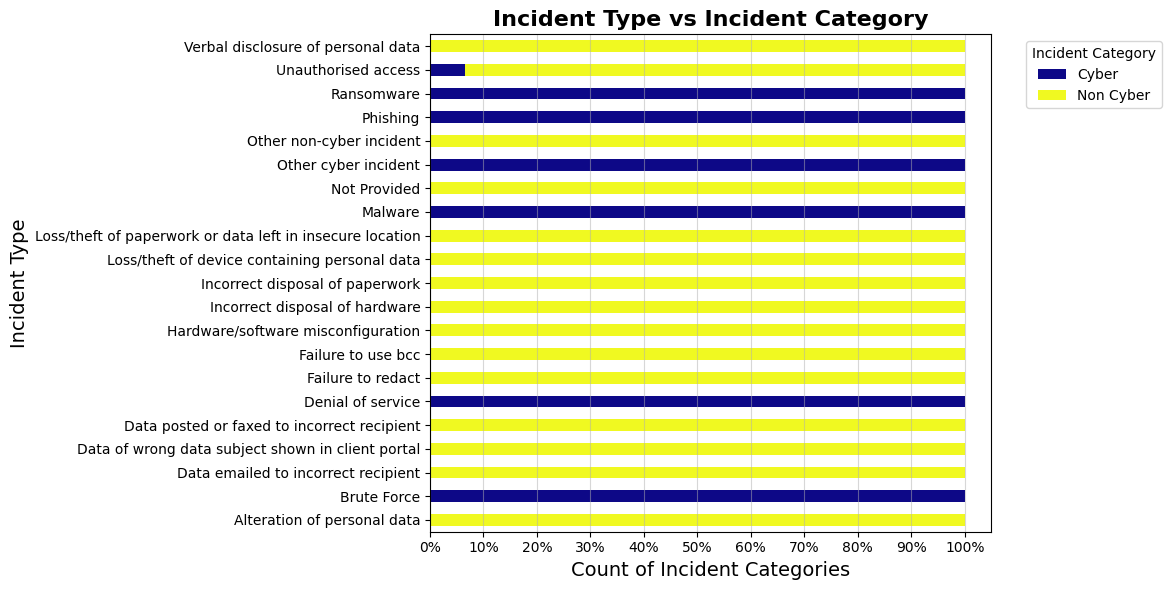

incident_category,Cyber,Non Cyber
incident_type,,
Alteration of personal data,0.000,1.000
Brute Force,1.000,0.000
Data emailed to incorrect recipient,0.000,1.000
Data of wrong data subject shown in client portal,0.000,1.000
Data posted or faxed to incorrect recipient,0.000,1.000
Denial of service,1.000,0.000
Failure to redact,0.000,1.000
Failure to use bcc,0.000,1.000
Hardware/software misconfiguration,0.000,1.000


In [160]:
# incident category vs incident Type

# proportions
incident_type_category_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['incident_category'],
    normalize='index'
)
# counts
incident_type_category_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['incident_category']
)
# horizontal bar chart
incident_type_category_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Incident Type vs Incident Category', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Count of Incident Categories', fontsize=14)
plt.yticks(rotation=0, ha='right')
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)]) 
plt.legend(title='Incident Category', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs incident category proportions
incident_type_category_proportions.round(3)


In [161]:
# table for the incident type vs incident category counts
incident_type_category_counts

incident_category,Cyber,Non Cyber
incident_type,,
Alteration of personal data,0,30
Brute Force,17,0
Data emailed to incorrect recipient,0,1347
Data of wrong data subject shown in client portal,0,240
Data posted or faxed to incorrect recipient,0,890
Denial of service,5,0
Failure to redact,0,329
Failure to use bcc,0,195
Hardware/software misconfiguration,0,304


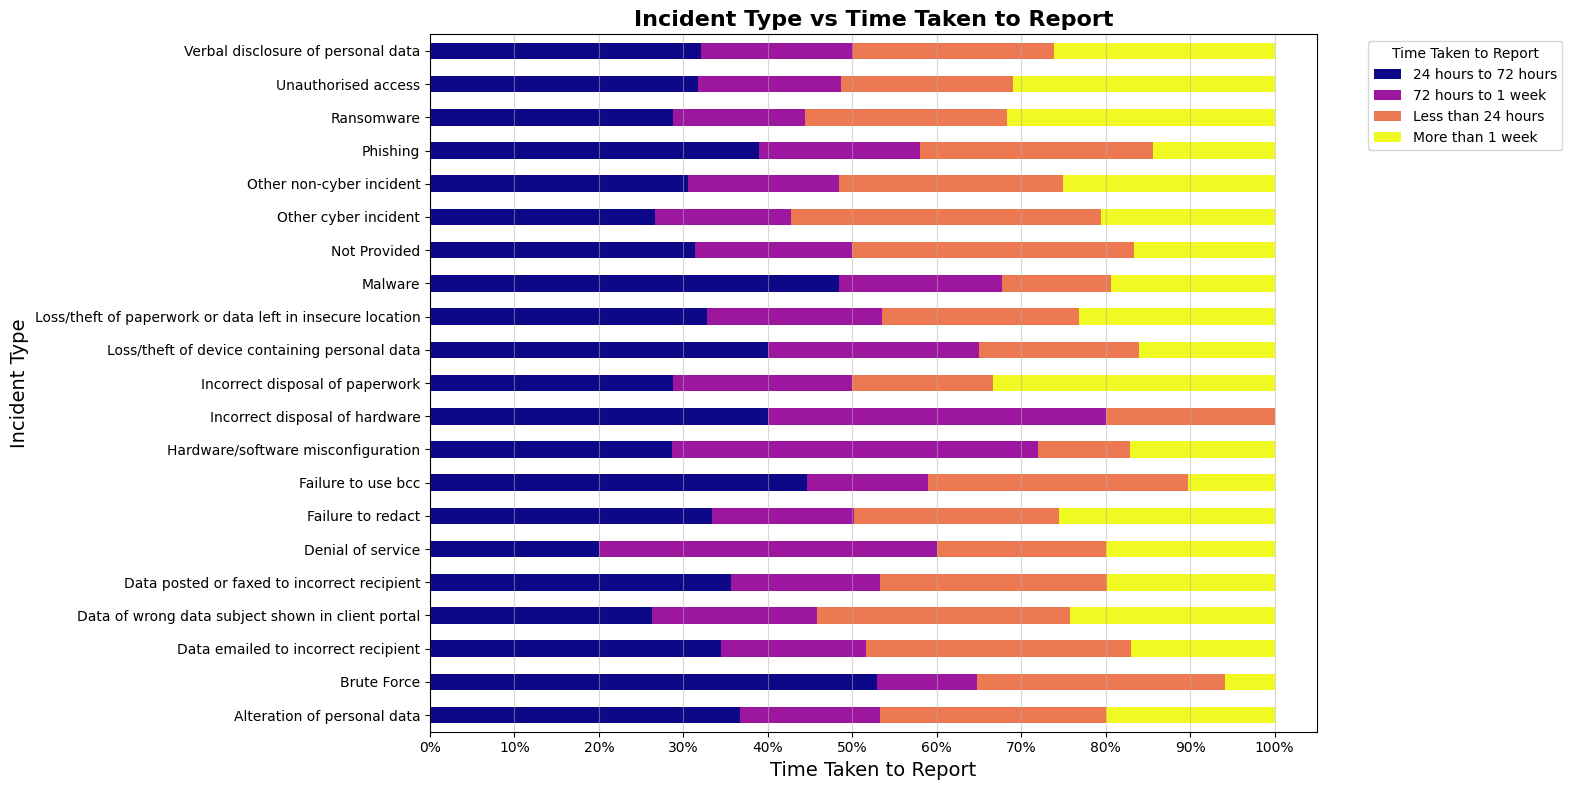

time_taken_to_report,24 hours to 72 hours,72 hours to 1 week,Less than 24 hours,More than 1 week
incident_type,,,,
Alteration of personal data,0.367,0.167,0.267,0.200
Brute Force,0.529,0.118,0.294,0.059
Data emailed to incorrect recipient,0.344,0.171,0.314,0.170
Data of wrong data subject shown in client portal,0.262,0.196,0.300,0.242
Data posted or faxed to incorrect recipient,0.356,0.176,0.269,0.199
Denial of service,0.200,0.400,0.200,0.200
Failure to redact,0.334,0.167,0.243,0.255
Failure to use bcc,0.446,0.144,0.308,0.103
Hardware/software misconfiguration,0.286,0.434,0.109,0.171


In [162]:
# incident type vs time taken to report

# proportions
incident_type_time_proportions = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['time_taken_to_report'],
    normalize='index'
)
# counts
incident_type_time_counts = pd.crosstab(
    df_health_unique['incident_type'],
    df_health_unique['time_taken_to_report']
)
# horizontal bar chart
incident_type_time_proportions.plot(
    kind='barh',
    stacked=True,
    figsize=(16, 8),
    colormap='plasma'
)

plt.title('Incident Type vs Time Taken to Report', fontsize=16, fontweight='bold')
plt.ylabel('Incident Type', fontsize=14)
plt.xlabel('Time Taken to Report', fontsize=14)
plt.yticks(rotation=0, ha='right')
plt.xticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)]) 
plt.legend(title='Time Taken to Report', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='x', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# table for the incident type vs time taken to report proportions
incident_type_time_proportions.round(3)

In [163]:
# table for the incident type vs time taken to report counts
incident_type_time_counts

time_taken_to_report,24 hours to 72 hours,72 hours to 1 week,Less than 24 hours,More than 1 week
incident_type,,,,
Alteration of personal data,11,5,8,6
Brute Force,9,2,5,1
Data emailed to incorrect recipient,464,231,423,229
Data of wrong data subject shown in client portal,63,47,72,58
Data posted or faxed to incorrect recipient,317,157,239,177
Denial of service,1,2,1,1
Failure to redact,110,55,80,84
Failure to use bcc,87,28,60,20
Hardware/software misconfiguration,87,132,33,52


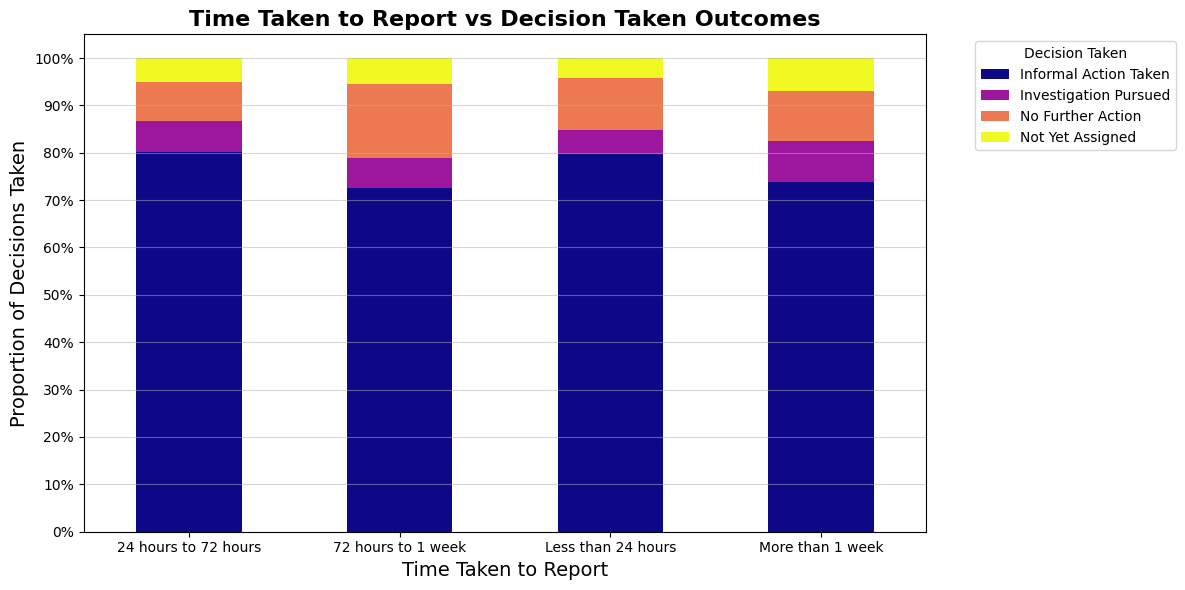

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
time_taken_to_report,,,,
24 hours to 72 hours,0.802,0.065,0.082,0.051
72 hours to 1 week,0.725,0.064,0.157,0.054
Less than 24 hours,0.797,0.051,0.109,0.043
More than 1 week,0.739,0.087,0.104,0.070


In [164]:
# decision taken vs time taken to report

# proportions
decision_time_proportions = pd.crosstab(
    df_health_unique['time_taken_to_report'],
    df_health_unique['decision_taken'],
    normalize='index'
)
# counts
decision_time_counts = pd.crosstab(
    df_health_unique['time_taken_to_report'],
    df_health_unique['decision_taken']
)
# bar chart
decision_time_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='plasma'
)

plt.title('Time Taken to Report vs Decision Taken Outcomes', fontsize=16, fontweight='bold')
plt.xlabel('Time Taken to Report', fontsize=14)
plt.xticks(rotation=0, ha='center')
plt.ylabel('Proportion of Decisions Taken', fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), [f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
plt.legend(title='Decision Taken', bbox_to_anchor=(1.05, 1), loc='best')
plt.grid(True, axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()     

# table for the time taken to report vs decision taken proportions
decision_time_proportions.round(3)

In [165]:
# table for the time taken to report vs decision taken counts
decision_time_counts

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
time_taken_to_report,,,,
24 hours to 72 hours,2307,188,235,146
72 hours to 1 week,1191,105,257,89
Less than 24 hours,1785,115,243,96
More than 1 week,1511,177,213,143



Number of People Affected across all Healthcare Incidents:
	1 to 9: 5,637 incidents (64.0%)
	10 to 99: 1,012 incidents (11.5%)
	100 to 1k: 661 incidents (7.5%)
	1k to 10k: 361 incidents (4.1%)
	10k to 100k: 132 incidents (1.5%)
	100k and above: 40 incidents (0.5%)
	Unknown: 958 incidents (10.9%)


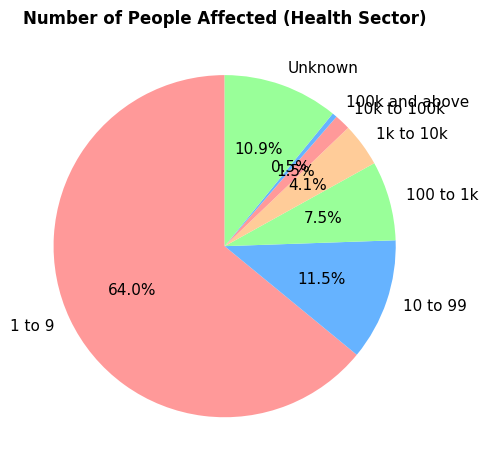


Incident Types across all Healthcare Incidents:
	Other non-cyber incident: 1,727 incidents (19.6%)
	Unauthorised access: 1,561 incidents (17.7%)
	Data emailed to incorrect recipient: 1,347 incidents (15.3%)
	Data posted or faxed to incorrect recipient: 890 incidents (10.1%)
	Loss/theft of paperwork or data left in insecure location: 733 incidents (8.3%)
	Verbal disclosure of personal data: 409 incidents (4.6%)
	Failure to redact: 329 incidents (3.7%)
	Hardware/software misconfiguration: 304 incidents (3.5%)
	Ransomware: 275 incidents (3.1%)
	Data of wrong data subject shown in client portal: 240 incidents (2.7%)
	Phishing: 236 incidents (2.7%)
	Other cyber incident: 199 incidents (2.3%)
	Failure to use bcc: 195 incidents (2.2%)
	Not Provided: 102 incidents (1.2%)
	Loss/theft of device containing personal data: 100 incidents (1.1%)
	Incorrect disposal of paperwork: 66 incidents (0.7%)
	Malware: 31 incidents (0.4%)
	Alteration of personal data: 30 incidents (0.3%)
	Brute Force: 17 incid

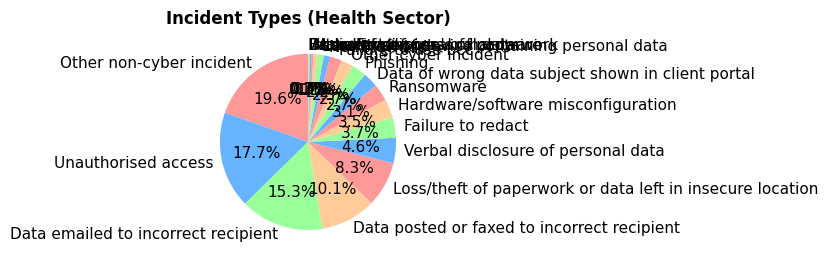


Time Taken to Report across all Healthcare Incidents:
	24 hours to 72 hours: 2,876 incidents (32.7%)
	Less than 24 hours: 2,239 incidents (25.4%)
	More than 1 week: 2,044 incidents (23.2%)
	72 hours to 1 week: 1,642 incidents (18.7%)


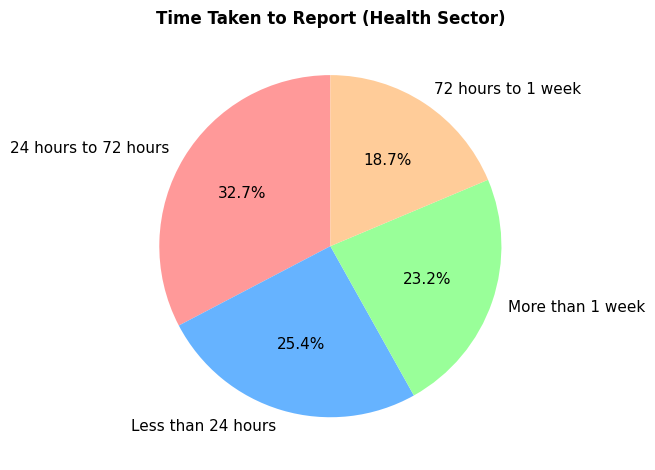

In [166]:
# proportion of number of people affected across all incidents
data_subjects_counts = df_health_unique['no_data_subjects_affected'].value_counts().sort_index()
data_subjects_percents = (data_subjects_counts / len(df_health_unique)) * 100
print(f"\nNumber of People Affected across all Healthcare Incidents:")
for category, count, percent in zip(data_subjects_counts.index, data_subjects_counts.values, data_subjects_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    

# pie chart of number of people affected
plt.title("Number of People Affected (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(data_subjects_counts.values,
        labels=data_subjects_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

# proportion of incident type across all incidents
incident_type_counts = df_health_unique['incident_type'].value_counts()
incident_type_percents = (incident_type_counts / len(df_health_unique)) * 100
print(f"\nIncident Types across all Healthcare Incidents:")
for category, count, percent in zip(incident_type_counts.index, incident_type_counts.values, incident_type_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    
# pie chart of incident types
plt.title("Incident Types (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(incident_type_counts.values,
        labels=incident_type_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

# proportion of time taken to report across all incidents
time_taken_counts = df_health_unique['time_taken_to_report'].value_counts()
time_taken_percents = (time_taken_counts / len(df_health_unique)) * 100
print(f"\nTime Taken to Report across all Healthcare Incidents:")
for category, count, percent in zip(time_taken_counts.index, time_taken_counts.values, time_taken_percents.values):
    print(f"\t{category}: {count:,} incidents ({percent:.1f}%)")
    
# pie chart of time taken to report
plt.title("Time Taken to Report (Health Sector)", fontsize=12, fontweight='bold')
plt.pie(time_taken_counts.values,
        labels=time_taken_counts.index,
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
        startangle=90,
        textprops={'fontsize': 11})
plt.tight_layout()
plt.show()

## Pre-ML Processing

**Goal**: Prepare dataset for ML modelling

**Issues**:
* Dataset imbalance
* Aggregation of data_type and data_subject_type

In [167]:
# create a new df for ML models - unique incidents with aggregated data_subject_type and data_type features
df_health_ml = (
    df_health_original
    .groupby("bi_reference", observed=True)
    .agg({
        "year": "first",
        "quarter": "first",
        "data_subject_type": lambda x: ', '.join(sorted(x.unique())),
        "data_type": lambda x: ', '.join(sorted(x.unique())),
        "decision_taken": "first",
        "incident_category": "first",
        "incident_type": "first",
        "no_data_subjects_affected": "first",
        "time_taken_to_report": "first",
    })
    .reset_index()
)

# verify new df
df_health_ml.info()
df_health_ml.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8801 entries, 0 to 8800
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               8801 non-null   category
 1   year                       8801 non-null   category
 2   quarter                    8801 non-null   category
 3   data_subject_type          8801 non-null   object  
 4   data_type                  8801 non-null   object  
 5   decision_taken             8801 non-null   category
 6   incident_category          8801 non-null   category
 7   incident_type              8801 non-null   category
 8   no_data_subjects_affected  8801 non-null   category
 9   time_taken_to_report       8801 non-null   category
dtypes: category(8), object(2)
memory usage: 543.8+ KB


,bi_reference,year,quarter,data_subject_type,data_type,decision_taken,incident_category,incident_type,no_data_subjects_affected,time_taken_to_report
0,BI24632,2021,Qtr 2,Unknown,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Loss/theft of paperwork or data left in insecu...,1 to 9,24 hours to 72 hours
1,BI24635,2021,Qtr 2,Patients,"Basic personal identifiers, Health data, Locat...",Informal Action Taken,Non Cyber,Loss/theft of paperwork or data left in insecu...,1 to 9,More than 1 week
2,BI24639,2021,Qtr 2,Patients,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,1 to 9,24 hours to 72 hours
3,BI24643,2021,Qtr 2,Patients,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Verbal disclosure of personal data,1 to 9,Less than 24 hours
4,BI24650,2021,Qtr 2,Unknown,Basic personal identifiers,Informal Action Taken,Non Cyber,Other non-cyber incident,1 to 9,Less than 24 hours
5,BI24659,2021,Qtr 2,Unknown,Unknown,Informal Action Taken,Non Cyber,Not Provided,Unknown,Less than 24 hours
6,BI24660,2021,Qtr 2,Patients,"Basic personal identifiers, Health data, Sex l...",Informal Action Taken,Non Cyber,Data posted or faxed to incorrect recipient,1 to 9,More than 1 week
7,BI24665,2021,Qtr 2,Employees,"Basic personal identifiers, Economic and finan...",Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,1k to 10k,Less than 24 hours
8,BI24676,2021,Qtr 2,Unknown,Unknown,Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,Unknown,Less than 24 hours
9,BI24677,2021,Qtr 2,Employees,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Not Provided,100 to 1k,72 hours to 1 week


In [168]:
# define the test period - train 2021 Q2 - 2024 Q4, test 2025 Q1 & Q2
def test_period(row):
    return ((row["year"] == 2025) and (row["quarter"] in ["Qtr 1", "Qtr 2"]))

# temp column to check train vs test split
df_health_ml["is_test"] = df_health_ml.apply(test_period, axis=1)
df_health_ml["is_test"].value_counts()

is_test
False    7627
True     1174
Name: count, dtype: int64

In [169]:
# split into train and test sets
df_train = df_health_ml[df_health_ml["is_test"] == False].reset_index(drop=True)
df_test = df_health_ml[df_health_ml["is_test"] == True].reset_index(drop=True)

# drop temp column
df_health_ml = df_health_ml.drop(columns=["is_test"])

# drop bi_reference as not needed for modelling
df_health_ml = df_health_ml.drop(columns=["bi_reference"])

# summary of years and quarters in train vs test sets
print("Training set:\n", df_train[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))
print("\nTest set:\n", df_test[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))


Training set:
       year quarter
0     2021   Qtr 2
603   2021   Qtr 3
1035  2021   Qtr 4
1496  2022   Qtr 1
1917  2022   Qtr 2
2348  2022   Qtr 3
2829  2022   Qtr 4
3269  2023   Qtr 1
3723  2023   Qtr 2
4181  2023   Qtr 3
4682  2023   Qtr 4
5185  2024   Qtr 1
5757  2024   Qtr 2
6373  2024   Qtr 3
7050  2024   Qtr 4

Test set:
      year quarter
0    2025   Qtr 1
584  2025   Qtr 2


In [170]:
df_health_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8801 entries, 0 to 8800
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   year                       8801 non-null   category
 1   quarter                    8801 non-null   category
 2   data_subject_type          8801 non-null   object  
 3   data_type                  8801 non-null   object  
 4   decision_taken             8801 non-null   category
 5   incident_category          8801 non-null   category
 6   incident_type              8801 non-null   category
 7   no_data_subjects_affected  8801 non-null   category
 8   time_taken_to_report       8801 non-null   category
dtypes: category(7), object(2)
memory usage: 199.8+ KB


In [171]:
df_health_ml.head(10)

,year,quarter,data_subject_type,data_type,decision_taken,incident_category,incident_type,no_data_subjects_affected,time_taken_to_report
0,2021,Qtr 2,Unknown,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Loss/theft of paperwork or data left in insecu...,1 to 9,24 hours to 72 hours
1,2021,Qtr 2,Patients,"Basic personal identifiers, Health data, Locat...",Informal Action Taken,Non Cyber,Loss/theft of paperwork or data left in insecu...,1 to 9,More than 1 week
2,2021,Qtr 2,Patients,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,1 to 9,24 hours to 72 hours
3,2021,Qtr 2,Patients,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Verbal disclosure of personal data,1 to 9,Less than 24 hours
4,2021,Qtr 2,Unknown,Basic personal identifiers,Informal Action Taken,Non Cyber,Other non-cyber incident,1 to 9,Less than 24 hours
5,2021,Qtr 2,Unknown,Unknown,Informal Action Taken,Non Cyber,Not Provided,Unknown,Less than 24 hours
6,2021,Qtr 2,Patients,"Basic personal identifiers, Health data, Sex l...",Informal Action Taken,Non Cyber,Data posted or faxed to incorrect recipient,1 to 9,More than 1 week
7,2021,Qtr 2,Employees,"Basic personal identifiers, Economic and finan...",Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,1k to 10k,Less than 24 hours
8,2021,Qtr 2,Unknown,Unknown,Informal Action Taken,Non Cyber,Data emailed to incorrect recipient,Unknown,Less than 24 hours
9,2021,Qtr 2,Employees,"Basic personal identifiers, Health data",Informal Action Taken,Non Cyber,Not Provided,100 to 1k,72 hours to 1 week


In [172]:
# aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_ml
    .groupby(["year", "quarter"], observed=True) 
    .size()
    .reset_index(name="total_incidents")
)     

quarters = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

# merge the two summaries
incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])

# make the chronological order
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarters)

# convert year to int for sorting
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)

# x-axis label
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# copy for display purposes
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
# calculate the difference (duplicate count) & percentage of duplicates
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
display_df["duplicate_percent"] = (display_df["duplicates"] / display_df["total_incidents"] * 100).round(1)
# display columns
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates", "Duplicate %"]

# tabular form
print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

# summary statistics
print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")
print(f"\tAverage duplicate rate: {display_df['Duplicate %'].mean():.1f}%")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates  Duplicate %
2021   Qtr 2         603               603           0          0.0
2021   Qtr 3         432               432           0          0.0
2021   Qtr 4         461               461           0          0.0
2022   Qtr 1         421               421           0          0.0
2022   Qtr 2         431               431           0          0.0
2022   Qtr 3         481               481           0          0.0
2022   Qtr 4         440               440           0          0.0
2023   Qtr 1         454               454           0          0.0
2023   Qtr 2         458               458           0          0.0
2023   Qtr 3         501               501           0          0.0
2023   Qtr 4         503               503           0          0.0
2024   Qtr 1         572               572           0          0.0
2024   Qtr 2         616               616           0          0.0
20

In [173]:
# summary of decision_taken in train vs test sets
print("Training set decision_taken proportion:")
print(df_train["decision_taken"].value_counts(normalize=True))
print("\nTest set decision_taken proportion:")
print(df_test["decision_taken"].value_counts(normalize=True))

Training set decision_taken proportion:
decision_taken
Informal Action Taken    0.764914
No Further Action        0.119313
Investigation Pursued    0.074472
Not Yet Assigned         0.041301
Name: proportion, dtype: float64

Test set decision_taken proportion:
decision_taken
Informal Action Taken    0.817717
Not Yet Assigned         0.135434
No Further Action        0.032368
Investigation Pursued    0.014480
Name: proportion, dtype: float64


In [174]:
# function for evaluation metrics 
def evaluate_model(y_true, y_pred, labels=None):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    # display confusion matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print(cm)
    '''
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.plasma)
    plt.title("Confusion Matrix")
    plt.show()
    '''
    
    print(f"Accuracy Score: {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0)}")
    print(f"Recall: {recall_score(y_true, y_pred, average='macro', zero_division=0)}")
    print(f"F1 Score: {f1_score(y_true, y_pred, average='macro', zero_division=0)}")

In [175]:
# Baseline random forest classifier
FEATURE_COLS = ["year","quarter", "incident_type", "incident_category", "no_data_subjects_affected", "time_taken_to_report"]
TARGET_COL = "decision_taken"

# Training and test sets
X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]

X_test = df_test[FEATURE_COLS]
y_test = df_test[TARGET_COL]

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train:", y_train.value_counts().sort_index().to_dict())
print("Test:", y_test.value_counts().sort_index().to_dict())

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_COLS)])

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
evaluate_model(y_test, y_pred)

Train size: 7627 Test size: 1174
Train: {'Informal Action Taken': 5834, 'Investigation Pursued': 568, 'No Further Action': 910, 'Not Yet Assigned': 315}
Test: {'Informal Action Taken': 960, 'Investigation Pursued': 17, 'No Further Action': 38, 'Not Yet Assigned': 159}
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.82      0.98      0.89       960
Investigation Pursued       0.12      0.06      0.08        17
    No Further Action       0.28      0.21      0.24        38
     Not Yet Assigned       0.00      0.00      0.00       159

             accuracy                           0.81      1174
            macro avg       0.31      0.31      0.30      1174
         weighted avg       0.69      0.81      0.74      1174

Confusion Matrix:
[[938   4  18   0]
 [ 16   1   0   0]
 [ 29   1   8   0]
 [154   2   3   0]]
Accuracy Score: 0.8066439522998297
Precision: 0.30646002031965547
Recall: 0.3116082946336429
F1 Score: 0.3